# 01. Разведочный анализ данных

**Задача:** предсказать месячную стоимость аренды квартиры по параметрам объявления.

**Данные:** [Apartment for Rent Classified](https://archive.ics.uci.edu/dataset/555/apartment+for+rent+classified),
UCI Machine Learning Repository
99 492 объявления об аренде жилья в США за период декабрь 2018 — декабрь 2019, 22 колонки.

In [3]:
import sys
from pathlib import Path

# чтобы работали импорты src.* при запуске из папки notebooks
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd

from src.data.load import load_raw
from src.data.clean import missing_report, outlier_bounds_iqr
from src.utils.seed import set_seed
from src.utils.warnings import silence_blas_warnings
from src.viz import plots

silence_blas_warnings()
set_seed()
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

In [4]:
df = load_raw()
print(f"Размер: {df.shape[0]} строк, {df.shape[1]} колонок")
df.head(3)

20:41:19 | INFO    | src.data.load | CSV уже распакован: /Users/dianochka_l/Desktop/Project_ML/data/raw/apartments_for_rent_classified_100K.csv
20:41:20 | INFO    | src.data.load | Загрузил сырые данные: 99492 строк, 22 колонок
Размер: 99492 строк, 22 колонок


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,"$2,195",Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",1250.0,"$1,250",Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,NaN,1395.0,"$1,395",Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332


## 1. Что вообще есть в данных

21 признак + таргет `price`. Смысл колонок по документации UCI:

| Колонка | Смысл |
|---|---|
| `id` | идентификатор объявления |
| `category` | тип объявления (аренда квартиры, коммерция, ...) |
| `title`, `body` | заголовок и текст объявления |
| `amenities` | мультиселект удобств через запятую |
| `bathrooms`, `bedrooms` | число санузлов и спален |
| `currency`, `price`, `price_display`, `price_type` | валюта, цена, цена строкой, единица измерения |
| `fee`, `has_photo`, `pets_allowed` | комиссия, наличие фото, разрешённые питомцы |
| `square_feet` | площадь в квадратных футах |
| `address`, `cityname`, `state`, `latitude`, `longitude` | геоданные |
| `source` | площадка-источник объявления |
| `time` | unix-время публикации |

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             99492 non-null  int64  
 1   category       99492 non-null  object 
 2   title          99492 non-null  object 
 3   body           99492 non-null  object 
 4   amenities      83448 non-null  object 
 5   bathrooms      99429 non-null  float64
 6   bedrooms       99368 non-null  float64
 7   currency       99492 non-null  object 
 8   fee            99492 non-null  object 
 9   has_photo      99492 non-null  object 
 10  pets_allowed   39068 non-null  object 
 11  price          99491 non-null  float64
 12  price_display  99491 non-null  object 
 13  price_type     99492 non-null  object 
 14  square_feet    99492 non-null  int64  
 15  address        7943 non-null   object 
 16  cityname       99190 non-null  object 
 17  state          99190 non-null  object 
 18  latitu

In [6]:
df.describe(include=[np.number]).T

,count,mean,std,min,25%,50%,75%,max
id,99492.0,5.358321e+09,1.847404e+08,5.121046e+09,5.197950e+09,5.508673e+09,5.509007e+09,5.669439e+09
bathrooms,99429.0,1.445323e+00,5.470206e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,9.000000e+00
bedrooms,99368.0,1.728212e+00,7.492005e-01,0.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,9.000000e+00
price,99491.0,1.527057e+03,9.042459e+02,1.000000e+02,1.013000e+03,1.350000e+03,1.795000e+03,5.250000e+04
square_feet,99492.0,9.564307e+02,4.175715e+02,1.010000e+02,7.290000e+02,9.000000e+02,1.115000e+03,5.000000e+04
latitude,99467.0,3.694799e+01,4.599461e+00,1.957380e+01,3.374650e+01,3.722820e+01,3.995300e+01,6.483320e+01
longitude,99467.0,-9.156866e+01,1.581717e+01,-1.593698e+02,-1.047919e+02,-8.456230e+01,-7.760820e+01,-6.877880e+01
time,99492.0,1.559665e+09,1.105077e+07,1.544174e+09,1.550832e+09,1.568745e+09,1.568767e+09,1.577391e+09


## 2. Пропуски

В исходном csv пропуски записаны строкой `null`, а не пустым значением — поэтому в `load_raw`
они перечислены в `na_values`. Без этого pandas прочитал бы их как обычный текст, и, например,
`bathrooms` осталась бы колонкой типа `object`.

In [7]:
report = missing_report(df)
report

,n_missing,pct_missing,dtype,n_unique
address,91549,92.02,object,7771
pets_allowed,60424,60.73,object,4
amenities,16044,16.13,object,9827
state,302,0.30,object,51
cityname,302,0.30,object,2979
bedrooms,124,0.12,float64,10
bathrooms,63,0.06,float64,16
longitude,25,0.03,float64,7270
latitude,25,0.03,float64,7212
id,0,0.00,int64,99408


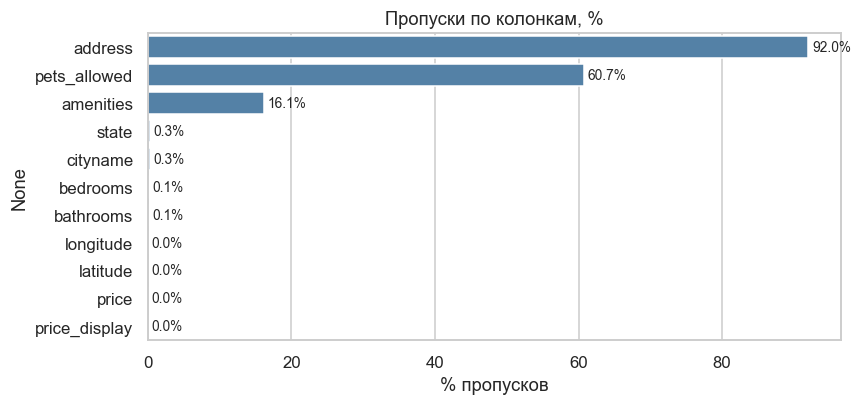

In [8]:
plots.plot_missing_values(df);

- `address` 92% пропусков. Удаляем, так как география уже полностью представлена в `cityname`, `state`,
  `latitude`, `longitude`, а восстанавливать адрес неоткуда
- `pets_allowed` — 61%. Поле заполняется галочками при подаче
  объявления, и пустое значение означает «ничего не отметили». Заполняем пустой строкой и заводим
  отдельный флаг `pets_not_specified`
- `amenities` — 16%. Та же обработка
- `cityname`, `state`, `latitude`, `longitude` менее 0.4%. Удаляем строки, так как гео слишком важно,
  чтобы его выдумывать, а потеря трёх сотен строк из 99 тысяч ни на что не влияет
- `bathrooms`, `bedrooms` — около 0.1%. Заполняем медианой, это не сдвинет распределение
- `price` — одна строка. Удаляем, так как без таргета строка бесполезна

## 3. Дубликаты

Проверяем два уровня: полностью совпадающие строки и повторяющиеся `id`.
Это важно сделать **до** разбиения на выборки — иначе одно и то же объявление
попадёт и в train, и в test, и оценка качества будет завышенной.

In [9]:
print("Полных дублей строк:", df.duplicated().sum())
print("Повторяющихся id:   ", df["id"].duplicated().sum())

# Неточные дубли: одна квартира, поданная несколько раз с разными id
dedup_keys = ["latitude", "longitude", "square_feet", "bedrooms", "bathrooms"]
approx = df.duplicated(subset=dedup_keys).sum()
print(f"Совпадений по {dedup_keys}: {approx} ({100 * approx / len(df):.1f}%)")

Полных дублей строк: 84
Повторяющихся id:    84
Совпадений по ['latitude', 'longitude', 'square_feet', 'bedrooms', 'bathrooms']: 37171 (37.4%)


Полных дублей всего 84, но по набору «координаты + площадь + комнаты» совпадает уже около трети
строк. Это повторные подачи одного и того же объекта. Получается делить данные нужно
по группам объектов, а не случайно по строкам. Проверяем это экспериментом в ноутбуке 02...

## 4. Единицы измерения цены

Прежде чем смотреть на распределение таргета, нужно убедиться, что все цены измерены одинаково.

In [10]:
print(df["price_type"].value_counts(dropna=False))
print()
print(df["currency"].value_counts(dropna=False))

price_type
Monthly           99488
Weekly                3
Monthly|Weekly        1
Name: count, dtype: int64

currency
USD    99492
Name: count, dtype: int64


In [11]:
# Как выглядят объявления с недельной ценой
df.loc[df["price_type"] != "Monthly", ["price", "price_type", "square_feet", "bedrooms", "cityname"]]

,price,price_type,square_feet,bedrooms,cityname
6729,1560.0,Weekly,200,1.0,New Bern
7245,275.0,Monthly|Weekly,300,NaN,Lakeland
49908,8500.0,Weekly,3600,4.0,East Hampton
83395,850.0,Weekly,2326,2.0,New York


Валюта везде одна (USD), а вот `price_type` — нет: есть 3 объявления с недельной ценой и одно
с `Monthly|Weekly`. Их всего четыре из 99 тысяч, но если этого не заметить, они превратятся
в «аномально дешёвые квартиры» и будут отброшены как ошибки ввода вместе с полезным сигналом.

В `clean.py` недельные цены пересчитываются в месячные умножением на 52/12.

## 5. Распределение таргета и выбросы

In [12]:
df["price"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999])

count    99491.000000
mean      1527.057281
std        904.245882
min        100.000000
1%         545.000000
5%         699.000000
25%       1013.000000
50%       1350.000000
75%       1795.000000
95%       2925.000000
99%       4250.000000
99.9%     9000.000000
max      52500.000000
Name: price, dtype: float64

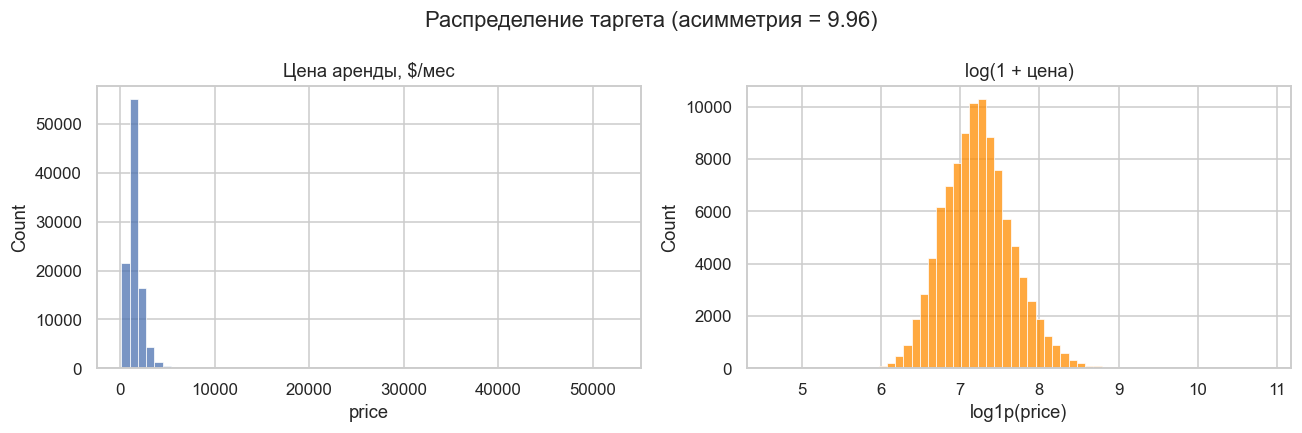

In [13]:
plots.plot_target_distribution(df);

In [14]:
low, high = outlier_bounds_iqr(df["price"])
print(f"Границы выбросов по IQR: [{low:.0f}, {high:.0f}]")
print(f"За границами IQR: {((df['price'] < low) | (df['price'] > high)).sum()} строк")
print()
print("Самые дорогие объявления:")
df.nlargest(10, "price")[["price", "square_feet", "bedrooms", "cityname", "state", "title"]]

Границы выбросов по IQR: [-160, 2968]
За границами IQR: 4698 строк

Самые дорогие объявления:


,price,square_feet,bedrooms,cityname,state,title
6863,52500.0,1418,0.0,Barstow,CA,Studio apartment for rent
40932,40000.0,7145,6.0,Los Angeles,CA,"Average Rent $40,000 a month - That's a STEAL!"
17131,35000.0,2269,4.0,West Hollywood,CA,Four BR - ready to move in.
28037,35000.0,5586,7.0,West Hollywood,CA,Pet Friendly 6+5 Apartment in West Hollywood
40715,35000.0,6366,6.0,West Hollywood,CA,"Stunning estate in the heart of /Sunset, just ..."
45817,33165.0,2211,3.0,Pacific Palisades,CA,Apartment in great location. 2 Car Garage!
38473,32000.0,5055,6.0,Los Angeles,CA,"Average Rent $32,000 a month - That's a STEAL...."
14400,30000.0,5872,5.0,Snowmass Village,CO,This mountain contemporary is truly one of a k...
31279,29500.0,4291,3.0,Venice,CA,Three BR Apartment - Located in the heart of o...
35034,29500.0,11000,6.0,Los Angeles,CA,Sexy secluded furnished estate. Parking Availa...


**Вывод по таргету** Распределение сильно скошено вправо, медиана 1350\$, а максимум 52 500\$.
Логарифм выпрямляет распределение почти до нормального — значит, гипотеза «обучать модель на
`log(price)`» стоит проверки в CP2... вот и узнаем

Введём пороги
- `price` от 200\$ до 10 000\$: ниже — ошибки ввода и объявления «от», выше — люксовый сегмент,
  который живёт по своим законам ценообразования и на 0.1% данных выучен не будет
- `square_feet` от 100 до 6 000 кв. футов

Эти пороги лежат в `src/config.py`

In [15]:
df["square_feet"].describe(percentiles=[0.01, 0.5, 0.99, 0.999])

count    99492.000000
mean       956.430688
std        417.571522
min        101.000000
1%         396.910000
50%        900.000000
99%       2260.000000
99.9%     3894.108000
max      50000.000000
Name: square_feet, dtype: float64

## 6. Зависимости в данных

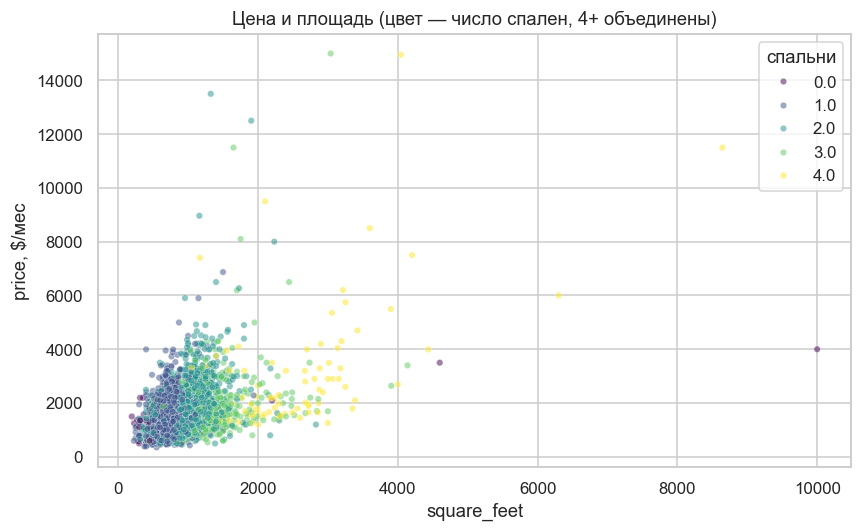

In [16]:
plots.plot_price_vs_area(df);

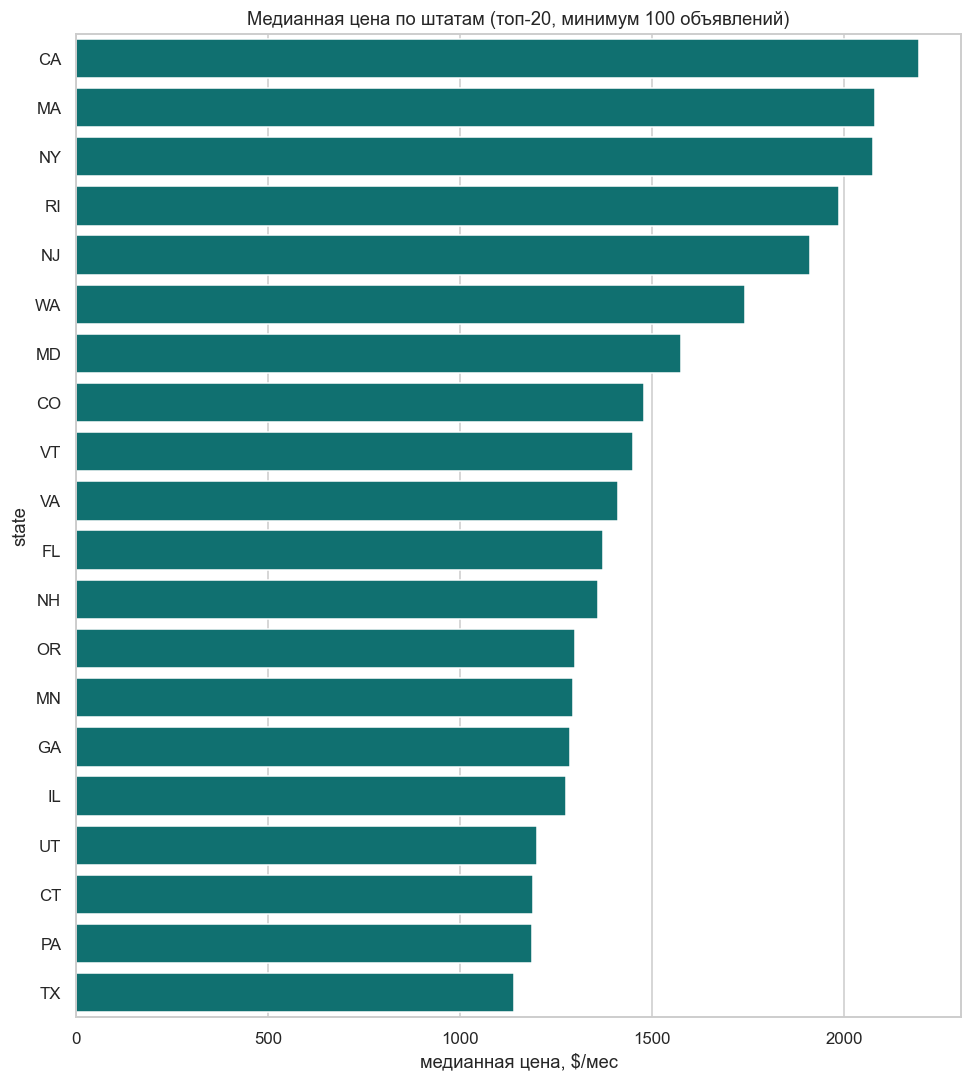

In [17]:
plots.plot_price_by_state(df);

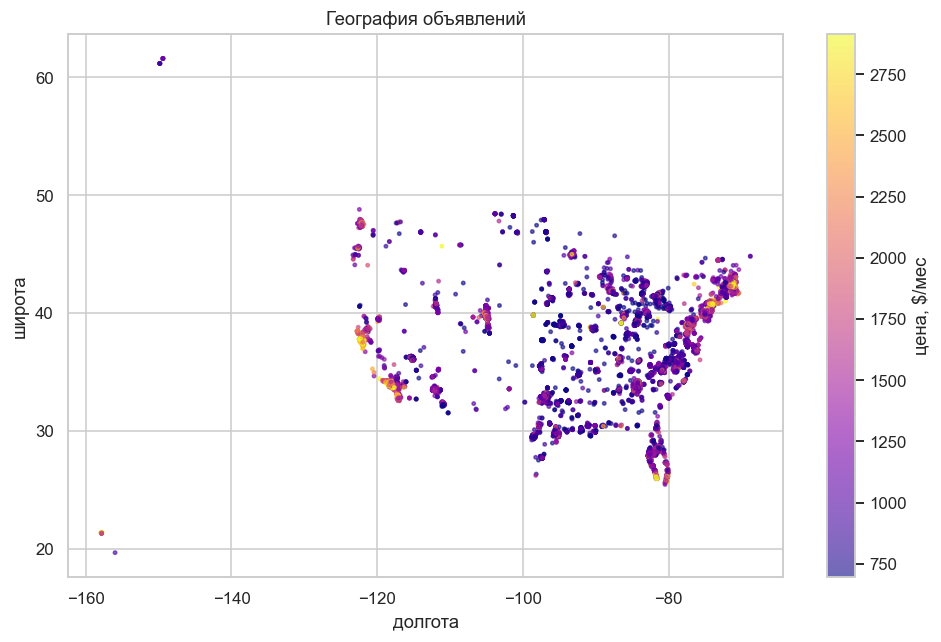

In [18]:
plots.plot_geo_scatter(df);

Видно, цена определяется в первую очередь географией, а не площадью...
Разброс медианных цен между штатами — в разы... Значит, гео-признаки должны быть в модели обязательно, а простое усреднение
по всей стране будет работать очень плохо.

In [19]:
# Категориальные признаки: насколько они вообще различают объявления
for column in ["category", "fee", "has_photo", "source"]:
    counts = df[column].value_counts(dropna=False)
    print(f"--- {column} ({df[column].nunique()} значений)")
    print(counts.head(5))
    print()

print("Городов:", df["cityname"].nunique())
print("Штатов: ", df["state"].nunique())

--- category (7 значений)
category
housing/rent/apartment            99431
housing/rent/commercial/retail       42
housing/rent                          7
housing/rent/home                     4
housing/rent/short_term               4
Name: count, dtype: int64

--- fee (2 значений)
fee
No     99291
Yes      201
Name: count, dtype: int64

--- has_photo (3 значений)
has_photo
Yes          55974
Thumbnail    34303
No            9215
Name: count, dtype: int64

--- source (25 значений)
source
RentDigs.com    90912
RentLingo        6924
ListedBuy         571
GoSection8        437
RealRentals       268
Name: count, dtype: int64

Городов: 2979
Штатов:  51


`category` практически константа (99.4% — `housing/rent/apartment`), `fee` тоже почти вырожденная
(99.8% — `No`). Пользы от них немного, но и вреда нет: оставляем, а решение об удалении
принимаем по важности признаков в CP2.

`cityname` — 2 979 уникальных значений. One-hot по нему раздует матрицу признаков, поэтому
в baseline его не берём, а корректное кодирование (target encoding внутри фолдов
кросс-валидации) делаем в CP2.

## 7. Удобства и питомцы

In [20]:
from collections import Counter

amenity_counter = Counter()
for value in df["amenities"].dropna():
    amenity_counter.update(value.split(","))

amenities_df = pd.DataFrame(amenity_counter.most_common(), columns=["amenity", "count"])
amenities_df["pct"] = (100 * amenities_df["count"] / len(df)).round(1)
amenities_df

,amenity,count,pct
0,Parking,43812,44.0
1,Pool,43496,43.7
2,Gym,37279,37.5
3,Patio/Deck,26502,26.6
4,Washer Dryer,25951,26.1
5,Storage,21582,21.7
6,Clubhouse,19064,19.2
7,Dishwasher,16595,16.7
8,AC,15777,15.9
9,Refrigerator,14906,15.0


In [21]:
pets_counter = Counter()
for value in df["pets_allowed"].dropna():
    pets_counter.update(value.split(","))
print(pets_counter.most_common())

[('Cats', 38941), ('Dogs', 37225), ('None', 1)]


27 уникальных удобств — разворачиваем их в 27 бинарных флагов плюс счётчик `amenities_count`
(длина списка сама по себе говорит о сегменте жилья). Питомцы дают два флага: `Cats` и `Dogs`.

## 8. Итоги
1. Пропуски есть и они разной природы... технические (гео, комнаты) и содержательные
   (незаполненные мультиселекты). Обрабатываются по-разному
2. 84 полных дубля и около трети строк — повторные подачи одного объекта.
   Это главный риск утечки при разбиении выборок
3. Четыре объявления с недельной ценой, которые надо привести к месячной
4. Таргет сильно скошен вправо, есть нереалистичные значения на обоих концах
5. Цена определяется прежде всего географией
6. `category`, `fee`, `currency` почти вырождены

В ноутбуке 2 содержится очистка по описанным правилам, генерация признаков
из мультиселектов, текста, гео и времени, разбор утечки таргета и честный сплит